In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler

from vimms_gym.env import DDAEnv
from vimms_gym.features import obs_to_dfs

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (20, 50)
mz_range = (100, 110)
rt_range = (400, 500)
intensity_range = (1E4, 1E20)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

Initialise a new DDA environment that tracks the top most intense peaks.

In [11]:
max_peaks = 100
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan)

In [12]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.131046         0.0       0.0         0.0   
 1      0.000000         0.0       0.0         0.0   
 2      0.000000         0.0       0.0         0.0   
 3      0.000000         0.0       0.0         0.0   
 4      0.000000         0.0       0.0         0.0   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0       0.0         0.0   
 96     0.000000         0.0       0.0         0.0   
 97     0.000000         0.0       0.0         0.0   
 98     0.000000         0.0       0.0         0.0   
 99     0.000000         0.0       0.0         0.0   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [13]:
observation['valid_actions']

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [14]:
env.features

[mz=103.83894795869402 rt=400 intensity=417.75782115354997 (0.13104622946950817) roi=ROI with data points=1 fragmentations=0 mz (103.8389-103.8389) rt (400.0000-400.0000)]

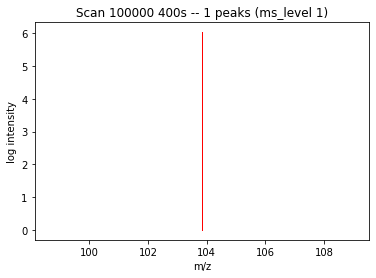

In [15]:
env.render()

Generate 10 ms1 scans

In [16]:
for i in range(10):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.1
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.827245         0.0  0.000000       0.000   
 1      0.507267         0.0  0.213333       0.068   
 2      0.501549         0.0  0.213333       0.060   
 3      0.144686         0.0  0.000000       0.000   
 4      0.000000         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                           0.000000                    0.000000   
 1                           0.011632                    0.493099   
 2                           0.011632                    0.486771   
 3                           0.000000                    0.000000   
 4   

In [41]:
observation['valid_actions']

array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [42]:
env.features

[mz=101.30393243686841 rt=407.1999999999996 intensity=3.5067346315705332e+16 (0.827245145117498) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (101.3039-101.3039) rt (407.2000-407.2000),
 mz=104.06207881822486 rt=407.1999999999996 intensity=13974842066.2178 (0.5072673454248543) fragmented=False roi=ROI with data points=11 fragmentations=0 mz (104.0621-104.0621) rt (400.4000-407.2000),
 mz=106.04702101972748 rt=407.1999999999996 intensity=10739290229.368351 (0.5015487789673632) fragmented=False roi=ROI with data points=9 fragmentations=0 mz (106.0470-106.0470) rt (401.2000-407.2000),
 mz=107.05632272914572 rt=407.1999999999996 intensity=782.9297184485147 (0.1446861389164394) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (107.0563-107.0563) rt (407.2000-407.2000)]

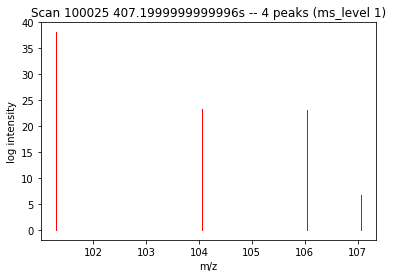

In [43]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [44]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.524864647477691
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.827245         1.0  0.026667       0.000   
 1      0.507267         0.0  0.240000       0.068   
 2      0.501549         0.0  0.240000       0.060   
 3      0.144686         0.0  0.000000       0.000   
 4      0.000000         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                           0.000000                    0.000000   
 1                           0.011632                    0.493099   
 2                           0.011632                    0.486771   
 3                           0.000000                    0.000000   
 4   

In [45]:
observation['valid_actions']

array([0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [46]:
env.features

[mz=101.30393243686841 rt=407.1999999999996 intensity=3.5067346315705332e+16 (0.827245145117498) fragmented=True roi=ROI with data points=1 fragmentations=0 mz (101.3039-101.3039) rt (407.2000-407.2000),
 mz=104.06207881822486 rt=407.1999999999996 intensity=13974842066.2178 (0.5072673454248543) fragmented=False roi=ROI with data points=11 fragmentations=0 mz (104.0621-104.0621) rt (400.4000-407.2000),
 mz=106.04702101972748 rt=407.1999999999996 intensity=10739290229.368351 (0.5015487789673632) fragmented=False roi=ROI with data points=9 fragmentations=0 mz (106.0470-106.0470) rt (401.2000-407.2000),
 mz=107.05632272914572 rt=407.1999999999996 intensity=782.9297184485147 (0.1446861389164394) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (107.0563-107.0563) rt (407.2000-407.2000)]

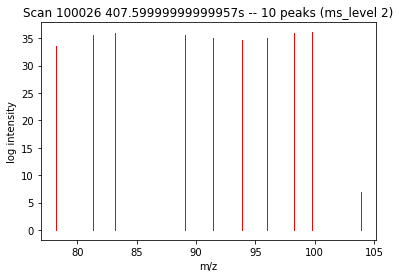

In [47]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [48]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward 0.09561892523428585
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.827245         1.0  0.040000       0.000   
 1      0.507267         1.0  0.253333       0.068   
 2      0.501549         0.0  0.253333       0.060   
 3      0.144686         0.0  0.000000       0.000   
 4      0.000000         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                           0.000000                    0.000000   
 1                           0.011632                    0.493099   
 2                           0.011632                    0.486771   
 3                           0.000000                    0.000000   
 4   

In [49]:
observation['valid_actions']

array([0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [50]:
env.features

[mz=101.30393243686841 rt=407.1999999999996 intensity=3.5067346315705332e+16 (0.827245145117498) fragmented=True roi=ROI with data points=1 fragmentations=0 mz (101.3039-101.3039) rt (407.2000-407.2000),
 mz=104.06207881822486 rt=407.1999999999996 intensity=13974842066.2178 (0.5072673454248543) fragmented=True roi=ROI with data points=11 fragmentations=0 mz (104.0621-104.0621) rt (400.4000-407.2000),
 mz=106.04702101972748 rt=407.1999999999996 intensity=10739290229.368351 (0.5015487789673632) fragmented=False roi=ROI with data points=9 fragmentations=0 mz (106.0470-106.0470) rt (401.2000-407.2000),
 mz=107.05632272914572 rt=407.1999999999996 intensity=782.9297184485147 (0.1446861389164394) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (107.0563-107.0563) rt (407.2000-407.2000)]

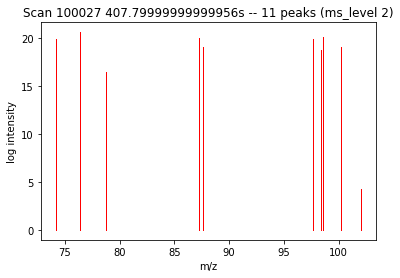

In [51]:
env.render()

Repeat targeting of the same precursor will end up producing 0 or negative reward.

In [52]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0


In [33]:
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

(    intensities  fragmented  excluded  roi_length  \
 0      0.493099         1.0  0.186667       0.036   
 1      0.486771         1.0  0.186667       0.028   
 2      0.147888         0.0  0.000000       0.000   
 3      0.000000         0.0  0.000000       0.000   
 4      0.000000         0.0  0.000000       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0  0.000000       0.000   
 96     0.000000         0.0  0.000000       0.000   
 97     0.000000         0.0  0.000000       0.000   
 98     0.000000         0.0  0.000000       0.000   
 99     0.000000         0.0  0.000000       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [34]:
observation['valid_actions']

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [35]:
env.features

[mz=104.06207881822486 rt=403.9999999999998 intensity=7277620133.457161 (0.49309946915876757) fragmented=True roi=ROI with data points=10 fragmentations=0 mz (104.0621-104.0621) rt (400.4000-404.0000),
 mz=106.04702101972748 rt=403.9999999999998 intensity=5437862719.361519 (0.4867714119741194) fragmented=True roi=ROI with data points=8 fragmentations=0 mz (106.0470-106.0470) rt (401.2000-404.0000),
 mz=104.64702308439188 rt=403.9999999999998 intensity=907.3082493397551 (0.1478877429772624) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (104.6470-104.6470) rt (404.0000-404.0000)]

Making an invalid move produces negative reward.

In [36]:
action = 90 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

reward -1.0
done False


(    intensities  fragmented  excluded  roi_length  \
 0      0.493099         1.0       0.2       0.036   
 1      0.486771         1.0       0.2       0.028   
 2      0.147888         0.0       0.0       0.000   
 3      0.000000         0.0       0.0       0.000   
 4      0.000000         0.0       0.0       0.000   
 ..          ...         ...       ...         ...   
 95     0.000000         0.0       0.0       0.000   
 96     0.000000         0.0       0.0       0.000   
 97     0.000000         0.0       0.0       0.000   
 98     0.000000         0.0       0.0       0.000   
 99     0.000000         0.0       0.0       0.000   
 
     roi_elapsed_time_since_last_frag  roi_intensity_at_last_frag  \
 0                                0.0                         0.0   
 1                                0.0                         0.0   
 2                                0.0                         0.0   
 3                                0.0                         0.0   
 4   

In [37]:
observation['valid_actions']

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [38]:
env.features

[mz=104.06207881822486 rt=403.9999999999998 intensity=7277620133.457161 (0.49309946915876757) fragmented=True roi=ROI with data points=10 fragmentations=0 mz (104.0621-104.0621) rt (400.4000-404.0000),
 mz=106.04702101972748 rt=403.9999999999998 intensity=5437862719.361519 (0.4867714119741194) fragmented=True roi=ROI with data points=8 fragmentations=0 mz (106.0470-106.0470) rt (401.2000-404.0000),
 mz=104.64702308439188 rt=403.9999999999998 intensity=907.3082493397551 (0.1478877429772624) fragmented=False roi=ROI with data points=1 fragmentations=0 mz (104.6470-104.6470) rt (404.0000-404.0000)]

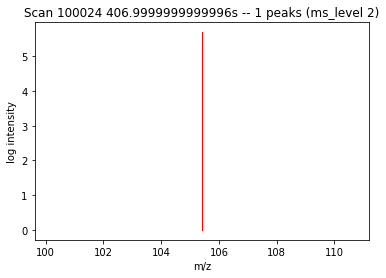

In [39]:
env.render()

Generate lots of MS1 scans

In [ ]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation, env.features)
scan_df, count_df

In [ ]:
observation['valid_actions']

In [ ]:
env.features

In [ ]:
env.render()